Initializing LPIPS model ('alex') on cuda...
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/poorna/venvs/torch/lib64/python3.11/site-packages/lpips/weights/v0.1/alex.pth
Loading videos...
Video: /home/poorna/Downloads/dataa/1st_10min/clip_009.mp4
  Resolution: 1920x1080
  FPS: 23.98
  Total Frames: 47

Video: ./output_videos_gemini/idx_9.mp4
  Resolution: 1280x720
  FPS: 24.0
  Total Frames: 192


Calculating LPIPS scores for 47 frames...


100%|██████████| 47/47 [00:01<00:00, 26.05it/s]



LPIPS Statistics (Lower is Better):
Mean LPIPS:    0.7813
Std Dev:       0.0104
Best (Min):    0.7665 (Frame 44)
Worst (Max):   0.8121 (Frame 1)



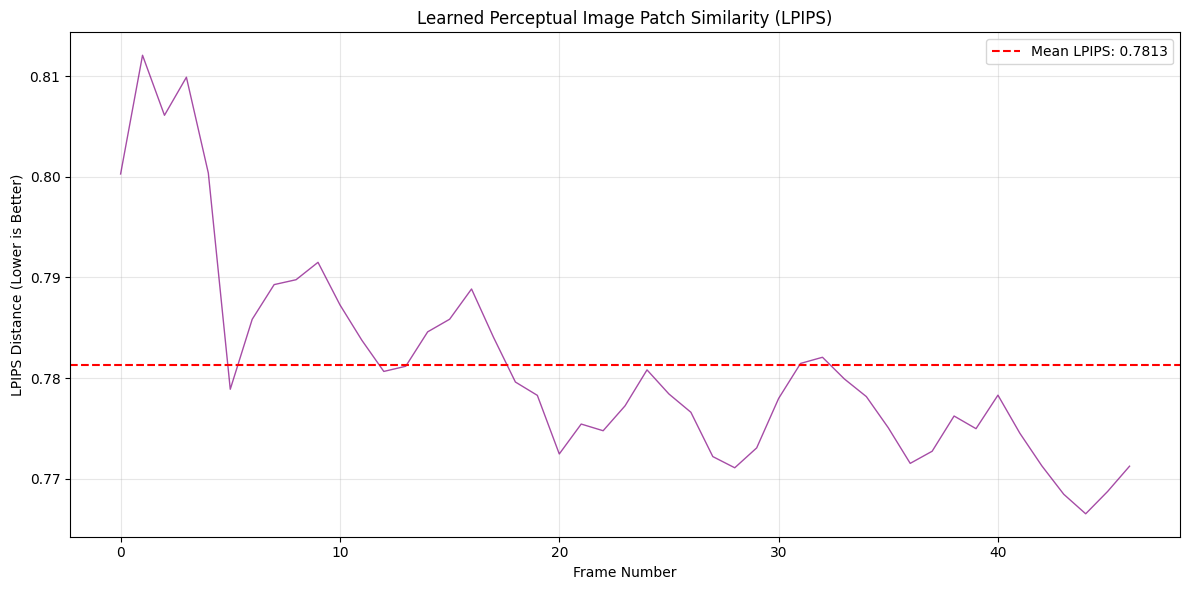

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import lpips
from tqdm import tqdm

def get_lpips_device():
    """Check for GPU availability"""
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

def preprocess_frame_for_lpips(frame, device):
    """
    Convert OpenCV frame (BGR, 0-255) to LPIPS Tensor (RGB, -1 to 1).
    """
    # 1. Convert BGR to RGB
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    # 2. Normalize to [-1, 1]
    # (Frame / 127.5) - 1.0 achieves the range -1 to 1
    frame = (frame.astype(np.float32) / 127.5) - 1.0
    
    # 3. Convert to Tensor: (H, W, C) -> (C, H, W)
    frame = frame.transpose((2, 0, 1))
    
    # 4. Add batch dimension: (1, C, H, W) and move to GPU/CPU
    frame_tensor = torch.from_numpy(frame).unsqueeze(0).to(device)
    
    return frame_tensor

def load_video(video_path):
    """Load video and return video capture object and properties"""
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
        raise ValueError(f"Error opening video file: {video_path}")
    
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    print(f"Video: {video_path}")
    print(f"  Resolution: {width}x{height}")
    print(f"  FPS: {fps}")
    print(f"  Total Frames: {frame_count}")
    print()
    
    return cap, fps, frame_count, width, height

def calculate_lpips_scores(video1_path, video2_path, net_type='alex'):
    """
    Calculate LPIPS distance between two videos frame by frame.
    net_type: 'alex' (faster) or 'vgg' (closer to traditional perceptual metrics)
    """
    
    # Setup LPIPS model
    device = get_lpips_device()
    print(f"Initializing LPIPS model ('{net_type}') on {device}...")
    loss_fn = lpips.LPIPS(net=net_type).to(device)
    loss_fn.eval() # Set to evaluation mode (no training)

    # Load both videos
    print("Loading videos...")
    cap1, fps1, frames1, w1, h1 = load_video(video1_path)
    cap2, fps2, frames2, w2, h2 = load_video(video2_path)
    
    # Handle Frame Count Mismatch
    min_frames = min(frames1, frames2)
    if frames1 != frames2:
        print(f"Warning: Mismatched frame counts ({frames1} vs {frames2}). Processing {min_frames} frames.")

    # Handle Resolution Mismatch
    if (w1, h1) != (w2, h2):
        print(f"Warning: Different resolutions. Resizing video 2 to match video 1 ({w1}x{h1}).")
    
    lpips_scores = []
    frame_numbers = []
    
    print(f"\nCalculating LPIPS scores for {min_frames} frames...")
    
    # Disable gradient calculation for speed/memory
    with torch.no_grad():
        for i in tqdm(range(min_frames)):
            ret1, frame1 = cap1.read()
            ret2, frame2 = cap2.read()
            
            if not ret1 or not ret2:
                break
            
            # Resize frame2 if dimensions don't match
            if (w1, h1) != (w2, h2):
                frame2 = cv2.resize(frame2, (w1, h1))
            
            # Preprocess for LPIPS (BGR->RGB, Norm, Tensor)
            tensor1 = preprocess_frame_for_lpips(frame1, device)
            tensor2 = preprocess_frame_for_lpips(frame2, device)
            
            # Calculate Distance
            # LPIPS returns a tensor (1,1,1,1), we need a float
            score = loss_fn(tensor1, tensor2).item()
            
            lpips_scores.append(score)
            frame_numbers.append(i)
    
    cap1.release()
    cap2.release()
    
    return np.array(lpips_scores), np.array(frame_numbers)

def plot_lpips_results(lpips_scores, frame_numbers):
    """Plot LPIPS scores over frames"""
    
    mean_val = np.mean(lpips_scores)
    std_val = np.std(lpips_scores)
    min_val = np.min(lpips_scores)
    max_val = np.max(lpips_scores)
    
    print(f"\n{'='*50}")
    print(f"LPIPS Statistics (Lower is Better):")
    print(f"{'='*50}")
    print(f"Mean LPIPS:    {mean_val:.4f}")
    print(f"Std Dev:       {std_val:.4f}")
    print(f"Best (Min):    {min_val:.4f} (Frame {frame_numbers[np.argmin(lpips_scores)]})")
    print(f"Worst (Max):   {max_val:.4f} (Frame {frame_numbers[np.argmax(lpips_scores)]})")
    print(f"{'='*50}\n")
    
    plt.figure(figsize=(12, 6))
    # Note: Inverted Y-axis is often used for Loss metrics, but here we keep standard
    # 0 = Perfect match, Higher = More different
    plt.plot(frame_numbers, lpips_scores, linewidth=1, color='purple', alpha=0.7)
    plt.axhline(y=mean_val, color='r', linestyle='--', label=f'Mean LPIPS: {mean_val:.4f}')
    
    plt.xlabel('Frame Number')
    plt.ylabel('LPIPS Distance (Lower is Better)')
    plt.title('Learned Perceptual Image Patch Similarity (LPIPS)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- Usage Example ---
v1 = "/home/poorna/Downloads/dataa/1st_10min/clip_009.mp4"
v2 = "./output_videos_gemini/idx_9.mp4"
scores, frames = calculate_lpips_scores(v1, v2)
plot_lpips_results(scores, frames)